In [31]:
# Imports

import torch
from datasets import load_dataset,Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from peft import get_peft_model, LoraConfig, TaskType
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,f1_score
from sklearn.model_selection import train_test_split
from huggingface_hub import HfApi
from dotenv import load_dotenv, find_dotenv



import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from torch import nn

print("torch:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

torch: 2.12.0
MPS available: True


In [32]:
#importing data

rows = []
with open("../data/raw/Sentences_AllAgree.txt", encoding="latin-1") as f:
    for line in f:
        line = line.strip()
        if "@" in line:
            sentence, label_str = line.rsplit("@", 1)
            rows.append({
                "sentence": sentence.strip(),
                "label_str": label_str.strip()
            })

df = pd.DataFrame(rows)

label_map = {"negative": 0, "neutral": 1, "positive": 2}
df["label"] = df["label_str"].map(label_map)

print(f"Total samples: {len(df)}")
print("\nLabel distribution:")
print(df["label_str"].value_counts())
print("\nSample:")
print(df.head(3))

Total samples: 2264

Label distribution:
label_str
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

Sample:
                                            sentence label_str  label
0  According to Gran , the company has no plans t...   neutral      1
1  For the last quarter of 2010 , Componenta 's n...  positive      2
2  In the third quarter of 2010 , net sales incre...  positive      2


In [9]:
# Split into train, validation and test 

# Split: 80% train, 10% validation, 10% test
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])

print(f"Train:      {len(train_df)} samples")
print(f"Validation: {len(val_df)} samples")
print(f"Test:       {len(test_df)} samples")

# Verify stratification held
print("\nTrain label distribution:")
print(train_df["label_str"].value_counts())

# Convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[["sentence", "label"]].reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df[["sentence", "label"]].reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df[["sentence", "label"]].reset_index(drop=True))

dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})

print("\nDataset ready:")
print(dataset)

Train:      1811 samples
Validation: 226 samples
Test:       227 samples

Train label distribution:
label_str
neutral     1113
positive     456
negative     242
Name: count, dtype: int64

Dataset ready:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 1811
    })
    validation: Dataset({
        features: ['sentence', 'label'],
        num_rows: 226
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 227
    })
})


In [10]:
#Tokenization

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset_tokenized = dataset.map(tokenize, batched=True)

print("Tokenization done")
print(dataset_tokenized)
print("\nSample tokenized:")
print(dataset_tokenized["train"][0])

Map:   0%|          | 0/1811 [00:00<?, ? examples/s]

Map:   0%|          | 0/226 [00:00<?, ? examples/s]

Map:   0%|          | 0/227 [00:00<?, ? examples/s]

Tokenization done
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1811
    })
    validation: Dataset({
        features: ['sentence', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 226
    })
    test: Dataset({
        features: ['sentence', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 227
    })
})

Sample tokenized:
{'sentence': "Merrill Lynch analyst Campbell Morgan upgraded his recommendation on PaperlinX from `` neutral '' to `` buy '' in May .", 'label': 2, 'input_ids': [101, 16239, 11404, 12941, 6063, 5253, 9725, 2010, 12832, 2006, 3259, 4115, 2595, 2013, 1036, 1036, 8699, 1005, 1005, 2000, 1036, 1036, 4965, 1005, 1005, 1999, 2089, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Why DistilBERT?

**The short answer:** it's the right tool for this job — fast, small, and good enough.

### DistilBERT vs the alternatives

| Model       | Size        | Speed         | Best for                |
|-------------|-------------|---------------|-------------------------|
| DistilBERT  | 66M params  | ⚡ Fast       | Production classifiers  |
| BERT-base   | 110M params | Medium        | When accuracy > speed   |
| RoBERTa     | 125M params | Slow          | Research benchmarks     |
| GPT-4 API   | Huge        | Slow + costly | Generation tasks        |

### Two reasons for this project

**1. 40% smaller than BERT with 97% of the performance.**
DistilBERT was trained by distilling BERT — a student model that learned to mimic the teacher. For a 3-class classifier on short sentences, that 3% gap is invisible.

**2. Runs on Mac M-series without choking.**
With only 2,264 samples i will iterate many times — speed matters. DistilBERT trains a full epoch in seconds on MPS.


In [11]:
# Load the model and apply LoRA

# Label mappings
id2label = {0: "negative", 1: "neutral", 2: "positive"}
label2id = {"negative": 0, "neutral": 1, "positive": 2}

# Load base DistilBERT
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# LoRA config
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"]
)

model = get_peft_model(model, lora_config)

# Confirm how few parameters we're actually training
model.print_trainable_parameters()

# Set device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"\nDevice: {device}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 887,811 || all params: 67,843,590 || trainable%: 1.3086

Device: mps


In [14]:
# Handle imbalance from earlier 

# Compute class weights to handle imbalance
class_counts = df["label"].value_counts().sort_index().values
total = len(df)
class_weights = total / (3 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:")
print(f"  negative (0): {class_weights[0]:.3f}")
print(f"  neutral  (1): {class_weights[1]:.3f}")
print(f"  positive (2): {class_weights[2]:.3f}")

# Custom Trainer that uses weighted loss

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = nn.CrossEntropyLoss(weight=class_weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

Class weights:
  negative (0): 2.491
  neutral  (1): 0.543
  positive (2): 1.324


## Class Weights — Handling Imbalance

The dataset is imbalanced:
- neutral:  1,391 samples (61%)
- positive:  570 samples (25%)
- negative:  303 samples (13%)

Without correction, the model learns to predict "neutral" for everything
and still gets 61% accuracy — which looks decent but is useless in production.

### The fix: weighted cross-entropy loss

We penalize the model more for missing rare classes.
The weight formula is: total / (num_classes × class_count)

| Class    | Count | Weight | Effect                        |
|----------|-------|--------|-------------------------------|
| negative | 303   | 2.491  | Mistakes cost 2.5x more       |
| neutral  | 1391  | 0.543  | Mistakes cost half as much    |
| positive | 570   | 1.324  | Mistakes cost 1.3x more       |

This forces the model to take negative sentences seriously
even though it sees far fewer of them during training.

In [20]:
#Training Arguments

# Metrics function called after each epoch
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    return {"accuracy": acc, "f1_weighted": f1}

# Training arguments
training_args = TrainingArguments(
    output_dir="../models/sentiment",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    logging_dir="../models/sentiment/logs",
    logging_steps=10,
    fp16=False,
    seed=42
)

# Build trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset_tokenized["train"],
    eval_dataset=dataset_tokenized["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Trainer ready — starting training...")
trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/Users/victorhugo/Desktop/financial_analyst/ai-financial-analyst/fin-env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Trainer ready — starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.312028,0.286947,0.907080,0.907171
2,0.142793,0.213942,0.946903,0.947212
3,0.069229,0.198183,0.951327,0.952028
4,0.109298,0.230463,0.951327,0.951819
5,0.028330,0.250842,0.946903,0.947167
6,0.021708,0.276925,0.951327,0.951581


/Users/victorhugo/Desktop/financial_analyst/ai-financial-analyst/fin-env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/victorhugo/Desktop/financial_analyst/ai-financial-analyst/fin-env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/victorhugo/Desktop/financial_analyst/ai-financial-analyst/fin-env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/victorhugo/Desktop/financial_analyst/ai-financial-analyst/fin-env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_m

TrainOutput(global_step=684, training_loss=0.19018285131158189, metrics={'train_runtime': 191.4641, 'train_samples_per_second': 94.587, 'train_steps_per_second': 5.954, 'total_flos': 367262966744064.0, 'train_loss': 0.19018285131158189, 'epoch': 6.0})

=== VALIDATION SET ===


/Users/victorhugo/Desktop/financial_analyst/ai-financial-analyst/fin-env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Weighted
0.021708,0.198183,6,0.951327,0.952028


{'eval_loss': 0.19818304479122162, 'eval_accuracy': 0.9513274336283186, 'eval_f1_weighted': 0.9520281150512071}

=== TEST SET (final honest score) ===


/Users/victorhugo/Desktop/financial_analyst/ai-financial-analyst/fin-env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Weighted
0.021708,0.200778,6,0.951542,0.952420


{'eval_loss': 0.20077785849571228, 'eval_accuracy': 0.9515418502202643, 'eval_f1_weighted': 0.9524197208617775}


/Users/victorhugo/Desktop/financial_analyst/ai-financial-analyst/fin-env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    negative       0.91      0.94      0.92        31
     neutral       1.00      0.95      0.97       139
    positive       0.87      0.96      0.92        57

    accuracy                           0.95       227
   macro avg       0.93      0.95      0.94       227
weighted avg       0.96      0.95      0.95       227



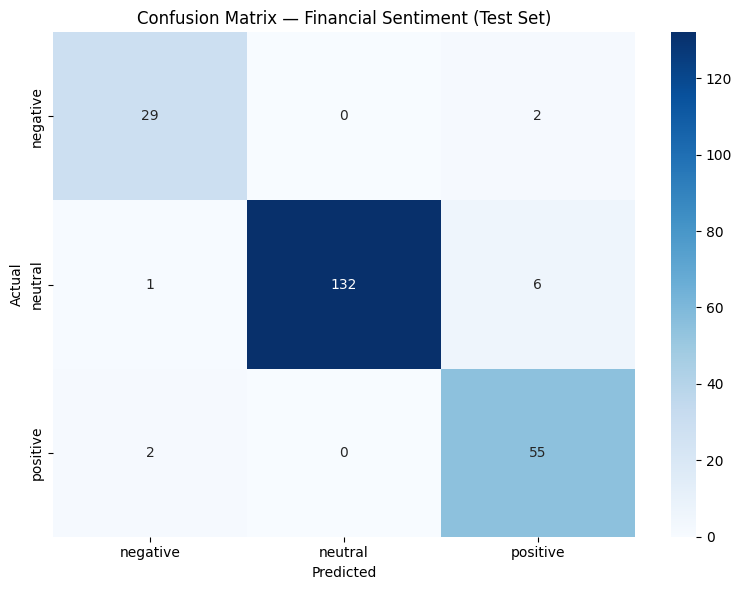


Confusion matrix saved.


In [21]:
# Evaluation and test

# Evaluate on validation
print("=== VALIDATION SET ===")
val_results = trainer.evaluate(dataset_tokenized["validation"])
print(val_results)

# Evaluate on test set — we open this ONCE
print("\n=== TEST SET (final honest score) ===")
test_results = trainer.evaluate(dataset_tokenized["test"])
print(test_results)

# Detailed classification report
predictions = trainer.predict(dataset_tokenized["test"])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    labels, preds,
    target_names=["negative", "neutral", "positive"]
))

# Confusion matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.title("Confusion Matrix — Financial Sentiment (Test Set)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../data/processed/confusion_matrix.png", dpi=150)
plt.show()
print("\nConfusion matrix saved.")

## Results — Financial Sentiment Classifier

**Model:** DistilBERT + LoRA (1.3% parameters trained)
**Dataset:** 2,264 financial sentences — FinPhraseBank AllAgree split
**Training:** 6 epochs, early stopping, 191 seconds on Apple MPS

### Scores

| Class    | Precision | Recall | F1   | Support |
|----------|-----------|--------|------|---------|
| negative | 0.91      | 0.94   | 0.92 | 31      |
| neutral  | 1.00      | 0.95   | 0.97 | 139     |
| positive | 0.87      | 0.96   | 0.92 | 57      |
| **weighted avg** | **0.96** | **0.95** | **0.95** | 227 |

### What the confusion matrix tells us

- Model almost never confuses negative with neutral — the most dangerous
  mistake in finance. Only 1 neutral was called negative, 0 negatives called neutral.
- Neutral scores F1 0.97 — most data, clearest language, easiest class.
- Negative and positive both at F1 0.92 — strong given negative had only 303 training samples.
  The class weights worked.

### The one weakness

Positive precision is 0.87 — the lowest of the three.
2 actual negative sentences were classified as positive.
In a real analyst tool this is the most dangerous error:
a negative signal being flagged as positive.
This is a known limitation to monitor in production.

In [33]:
# Upload to Hugging Face

load_dotenv(find_dotenv(), override=True)
HF_TOKEN = os.getenv("HF_TOKEN")

# Change this to your HuggingFace username
HF_USERNAME = "victorhrls"
REPO_NAME = "distilbert-financial-sentiment"
FULL_REPO = f"{HF_USERNAME}/{REPO_NAME}"

# Save locally first
model.save_pretrained("../models/sentiment")
tokenizer.save_pretrained("../models/sentiment")
print("Model saved locally to models/sentiment/")

# Push to Hugging Face Hub
model.push_to_hub(FULL_REPO, token=HF_TOKEN)
tokenizer.push_to_hub(FULL_REPO, token=HF_TOKEN)
print(f"\nModel pushed to: https://huggingface.co/{FULL_REPO}")